# Transferring of Mesenchymal cell states from the Gut Cell Atlas (Elementaite, 2021) to Remapped Data Using the `scVI - scANVI` Pipeline

**Developed by:** Anna Maguza\
**Affiliation:** Faculty of Medicine, Würzburg University\
**Creation date:** 6th January 2025\
**Last modified date:** 30th January 2025

#### **Objective**

This notebook outlines the process for transferring mesenchymal cell states annotations from the Gut Cell Atlas (Elementaite, 2021) to a series of remapped datasets using the `scVI - scANVI` pipeline. Our goal is to ensure consistent annotation of cell types across studies and to identify cells requiring manual validation.\
We analyze the confidence scores produced by `scANVI` to identify cells with low classification certainty. These cells are flagged for potential manual review and validation to ensure the accuracy of the annotations.\
Finally, we evaluate the performance of the `scVI` and `scANVI` models using `scIB` metrics. This step helps quantify the quality of the integration, classification, and batch correction.

## Import packages

In [12]:
import scvi
import torch
import anndata
import warnings
import numpy as np
import scanpy as sc
import anndata
import pandas as pd
import plotnine as p
import matplotlib.pyplot as plt
import seaborn as sns
from scib_metrics.benchmark import Benchmarker

import json
from datetime import datetime

## Setup working environment

In [13]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi = 180, color_map = 'magma_r', dpi_save = 300, vector_friendly = True, format = 'svg')

In [14]:
warnings.simplefilter(action = 'ignore')
scvi.settings.seed = 1712
%config InlineBackend.print_figure_kwargs = {'facecolor' : "w"}
%config InlineBackend.figure_format = 'retina'
torch.set_float32_matmul_precision('medium')

Seed set to 1712


In [15]:
arches_params = dict(
    use_layer_norm = "both",
    use_batch_norm = "none",
    encode_covariates = True,
    dropout_rate = 0.2,
    n_layers = 3,
)

In [16]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

In [17]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

In [18]:
timestamp = '30012025_144410'

## Upload data

In [19]:
adata = sc.read_h5ad('/Users/annamaguza/Desktop/data/gut_data/gut_hs_all_datasets_scVI_scANVI_celltypes_AM_10012025_100142_raw.h5ad')
adata

AnnData object with n_obs × n_vars = 402343 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoc

In [20]:
adata.obs['celltype'] = adata.obs['C_scANVI']

In [21]:
adata = adata[adata.obs['celltype'] == 'Mesenchymal']

In [22]:
del adata.obs['_scvi_batch'], adata.obs['_scvi_labels'], adata.obs['C_scANVI'], adata.obs['confidence_score']
del adata.obsm['X_scANVI'], adata.obsm['X_scVI'], adata.obsm['X_pca'], adata.obsm['umap_uncorrected'], adata.obsm['_scvi_extra_categorical_covs']
del adata.obsm['X_umap_qc']

In [23]:
X_is_raw(adata)

True

## Prepare observations

In [24]:
adata.obs['Protocol REF'] = adata.obs['Protocol REF'].cat.add_categories('Unknown')
adata.obs['Protocol REF'] = adata.obs['Protocol REF'].replace(['  '], 'Unknown')

In [25]:
adata.obs['Protocol REF'].value_counts()

Protocol REF
P-MTAB-101781    129093
P-MTAB-95162      32942
P-MTAB-100897     20117
P-MTAB-100978      2505
Unknown            1263
P-MTAB-102913       176
Name: count, dtype: int64

In [26]:
adata.obs['Performer'].value_counts()

Performer
University of Michigan DNA Sequencing core                                                           129093
Wellcome Sanger Institute                                                                             34205
Rasa Elmentaite, Kylie James                                                                          20117
Wellcome Sanger Institute Cellular Generation and Phenotyping teaml, Kylie James, Rasa Elmentaite      2505
University of Michigan Advanced Genomics Core                                                           176
Name: count, dtype: int64

In [27]:
adata.obs['library_construction'] = adata.obs['library_construction'].astype(str)
adata.obs['LIBRARY_LAYOUT'] = adata.obs['LIBRARY_LAYOUT'].astype(str)
adata.obs['library_construnction_and_layout'] = adata.obs['library_construction'] + '_' + adata.obs['LIBRARY_LAYOUT']
adata.obs['library_construnction_and_layout'].value_counts()

library_construnction_and_layout
10xV2_SINGLE    111206
10xV2_PAIRED     56827
10xV3_SINGLE     17887
10xV3_PAIRED       176
Name: count, dtype: int64

In [28]:
adata.obs['donor_id'] = adata.obs['donor_id'].cat.add_categories('cell_culture')
adata.obs['donor_id'] = adata.obs['donor_id'].replace(['nan'], 'cell_culture')

+ Delete samples with less than 10 cells

In [29]:
cell_counts = adata.obs['sample_id'].value_counts()
samples_to_remove = cell_counts[cell_counts < 10].index
adata = adata[~adata.obs['sample_id'].isin(samples_to_remove)].copy()

+ Delete not mesenchymal cell states 

In [30]:
adata.obs['Integrated_05'].value_counts()

Integrated_05
Unknown                         137576
Mesoderm 1 (HAND1+)              12015
Mesoderm 2 (ZEB2+)               10659
SMC (PLPP2+)                      4666
Stromal 3 (C7+)                   4090
Stromal 1 (ADAMDEC1+)             3123
cycling stromal                   2060
Stromal 2 (NPY+)                  1757
Stromal 2 (CH25H+)                1558
Immature pericyte                 1345
Transitional Stromal 3 (C3+)      1185
SMC (PART1/CAPN3+)                1105
myofibroblast (RSPO2+)            1090
Stromal 3 (KCNN3+)                 971
Stromal 1 (CCL11+)                 779
Contractile pericyte (PLN+)        462
Mesothelium                        381
angiogenic pericyte                320
ICC                                295
Mesothelium (RGS5+)                218
mLN Stroma (FMO2+)                 123
mLTo                                84
myofibroblast                       56
Mesothelium (PRG4+)                 42
Pericyte                            18
FDC        

In [31]:
adata = adata[adata.obs['Integrated_05'] != 'cycling ENCC/glia']
adata = adata[adata.obs['Integrated_05'] != 'Germ']
adata = adata[adata.obs['Integrated_05'] != 'FDC']

+ Relabel into broader annotation

In [32]:
cell_map = {
    'Mesoderm 1 (HAND1+)': 'Mesoderm',
    'Mesoderm 2 (ZEB2+)': 'Mesoderm',
    'SMC (PLPP2+)': 'SMC',
    'SMC (PART1/CAPN3+)': 'SMC',
    'Stromal 1 (ADAMDEC1+)': 'Stromal',
    'Stromal 1 (CCL11+)': 'Stromal',
    'Stromal 2 (NPY+)': 'Stromal',
    'Stromal 2 (CH25H+)': 'Stromal',
    'Stromal 3 (C7+)': 'Stromal',
    'Stromal 3 (C3+)': 'Stromal',
    'Stromal 3 (KCNN3+)': 'Stromal',
    'Stromal 4 (MMP1+)': 'Stromal',
    'cycling stromal': 'Stromal',
    'Transitional Stromal 3 (C3+)': 'Stromal',
    'Immature pericyte': 'Pericyte',
    'Contractile pericyte (PLN+)': 'Pericyte',
    'angiogenic pericyte': 'Pericyte',
    'Pericyte': 'Pericyte',
    'myofibroblast (RSPO2+)': 'Myofibroblast',
    'myofibroblast': 'Myofibroblast',
    'Mesothelium': 'Mesothelium',
    'Mesothelium (RGS5+)': 'Mesothelium',
    'Mesothelium (PRG4+)': 'Mesothelium',
    'mLN Stroma (FMO2+)': 'Lymphoid_Stroma',
    'mLTo': 'Lymphoid_Stroma',
    'FDC': 'Lymphoid_Stroma',
    'T reticular': 'Lymphoid_Stroma',
    'ICC': 'ICC',
    'Unknown': 'Unknown',
}

In [33]:
adata.obs['cell_states'] = adata.obs['Integrated_05'].map(cell_map)

+ Delete doublets

In [34]:
adata = adata[adata.obs['predicted_doublets'] != 'True']

+ Fix issue with Boolean None

In [35]:
adata.obs['cell_type'] = adata.obs['cell_type'].replace(['  '], 'unsorted')
adata.obs['cell_type'] = adata.obs['cell_type'].replace(['epithelial cell'], 'intestinal epithelial cell')
adata.obs['cell_type'] = adata.obs['cell_type'].cat.remove_unused_categories()
adata.obs['cell_type'] = adata.obs['cell_type'].fillna('unsorted')

In [36]:
adata.obs['cluster_passed_qc'] = adata.obs['cluster_passed_qc'].astype(str)
adata.obs['cluster_passed_qc'] = adata.obs['cluster_passed_qc'].fillna('N/A')
adata.obs['consensus_fraction'] = adata.obs['consensus_fraction'].astype(str)
adata.obs['consensus_fraction'] = adata.obs['consensus_fraction'].fillna('N/A')
adata.obs['consensus_passed_qc'] = adata.obs['consensus_passed_qc'].astype(str)
adata.obs['consensus_passed_qc'] = adata.obs['consensus_passed_qc'].fillna('N/A')
adata.obs['qc_cluster'] = adata.obs['qc_cluster'].astype(str)
adata.obs['qc_cluster'] = adata.obs['qc_cluster'].fillna('N/A')

In [37]:
adata.obs['gestational_age'] = adata.obs['gestational_age'].cat.add_categories('N/A - not fetal')
adata.obs['gestational_age'] = adata.obs['gestational_age'].replace(['  '], 'N/A - not fetal')
adata.obs['gestational_age'] = adata.obs['gestational_age'].fillna('N/A - not fetal')
adata.obs['gestational_age'].value_counts()

gestational_age
N/A - not fetal    152741
10.4                 6530
11.9                 6094
8.1                  5575
8.7                  4227
11.2                 3242
8.9                  3111
12.2                 1454
9.9                  1368
8.5                   514
8.4                   171
Name: count, dtype: int64

In [38]:
adata.obs['passage'] = adata.obs['passage'].cat.add_categories('N/A')
adata.obs['passage'] = adata.obs['passage'].replace(['  '], 'N/A')
adata.obs['passage'] = adata.obs['passage'].fillna('N/A')
adata.obs['passage'].value_counts()

passage
N/A    184342
2         514
1         171
Name: count, dtype: int64

In [39]:
adata.obs['batch'] = adata.obs['batch'].cat.add_categories('unknown')
adata.obs['batch'] = adata.obs['batch'].fillna('unknown')

In [40]:
adata.obs['sampling_site'] = adata.obs['sampling_site'].cat.add_categories('unknown')
adata.obs['sampling_site'] = adata.obs['sampling_site'].replace(['  '], 'unknown')
adata.obs['sampling_site'] = adata.obs['sampling_site'].fillna('unknown')

In [41]:
adata.obs['time'] = adata.obs['time'].fillna('N/A')

In [42]:
nan_summary = adata.obs.isna().sum()

print(nan_summary[nan_summary > 0])

Series([], dtype: int64)


## Visualize uncorrected dataset

In [43]:
adata_log = adata.copy()
sc.pp.normalize_total(adata_log, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(adata_log)

normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['S100A6', 'ACTG2', 'MFSD1', 'APOD', 'ENSG00000286848', 'CXCL10', 'CXCL13', 'ATG10', 'CXCL14', 'GPX3', 'MLN', 'LINC01013', 'COL1A2', 'ADAMDEC1', 'RPL30-AS1', 'CCL19', 'CCL21', 'TPM2', 'GSN', 'VIM-AS1', 'C10orf55', 'ADIRF-AS1', 'ACTA2', 'BEST1', 'TALAM1', 'TAGLN', 'ENSG00000272173', 'MGP', 'ENSG00000273149', 'FOS', 'THBS1', 'RPLP1', 'HBA2', 'CCL2', 'CCL11', 'COL1A1', 'ENSG00000267598', 'ZFP36', 'FTL', 'TMSB4X', 'MT-RNR1', 'MT-RNR2', 'MT-CO1', 'MT-CO2']
    finished (0:00:00)


In [44]:
sc.pp.pca(adata_log)

computing PCA
    with n_comps=50
    finished (0:01:42)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [45]:
sc.pp.neighbors(adata_log, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata_log)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:20)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:52)


In [46]:
adata.obsm['X_pca'] = adata_log.obsm['X_pca'].copy()
adata.obsm['umap_uncorrected'] = adata_log.obsm['X_umap'].copy()

In [47]:
del adata_log

In [48]:
adata_raw = adata.copy()

## Extract highly variable genes

We extract the highly variable genes from the old reference dataset.

In [49]:
adata_ref = sc.read_h5ad('data/gut_data/Integrated_4_datasets_05042024.h5ad')

In [50]:
adata_ref.layers["counts"] = adata_ref.X.copy()

In [51]:
sc.pp.highly_variable_genes(
    adata_ref,
    flavor = "seurat_v3",
    n_top_genes = 7000,
    layer = "counts",
    batch_key = "Library_Preparation_Protocol",
    subset = True,
    span = 1
)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


In [52]:
genes_to_keep = adata_ref.var_names.intersection(adata.var_names)
adata = adata[:, genes_to_keep].copy()

In [53]:
del adata_ref

## Run scVI

In [54]:
adata.layers['counts'] = adata.X.copy()

In [55]:
scvi.model.SCVI.setup_anndata(adata, 
                              categorical_covariate_keys=['sample_id', 'library_construnction_and_layout', 'Performer', 'Protocol REF'],
                              labels_key = "cell_states", 
                              layer = 'counts')

In [56]:
scvi_model = scvi.model.SCVI(adata,
                            n_latent = 150, 
                            n_hidden = 256,
                            n_layers = 3, 
                            dropout_rate = 0.1,
                            dispersion = 'gene-cell', 
                            gene_likelihood = 'nb')

In [57]:
scvi_model.train(300, 
                early_stopping = True,
                early_stopping_patience = 10,
                check_val_every_n_epoch = 1, 
                enable_progress_bar = True)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 299/300: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 299/300 [5:22:16<01:04, 64.67s/it, v_num=1, train_loss_step=990, train_loss_epoch=981]
Monitored metric elbo_validation did not improve in the last 10 records. Best score: 985.180. Signaling Trainer to stop.


In [58]:
adata.obsm["X_scVI"] = scvi_model.get_latent_representation(adata)

#### Evaluate model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [59]:
history_df = (
    scvi_model.history['elbo_train'].astype(float)
    .join(scvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars=['epoch'])
)

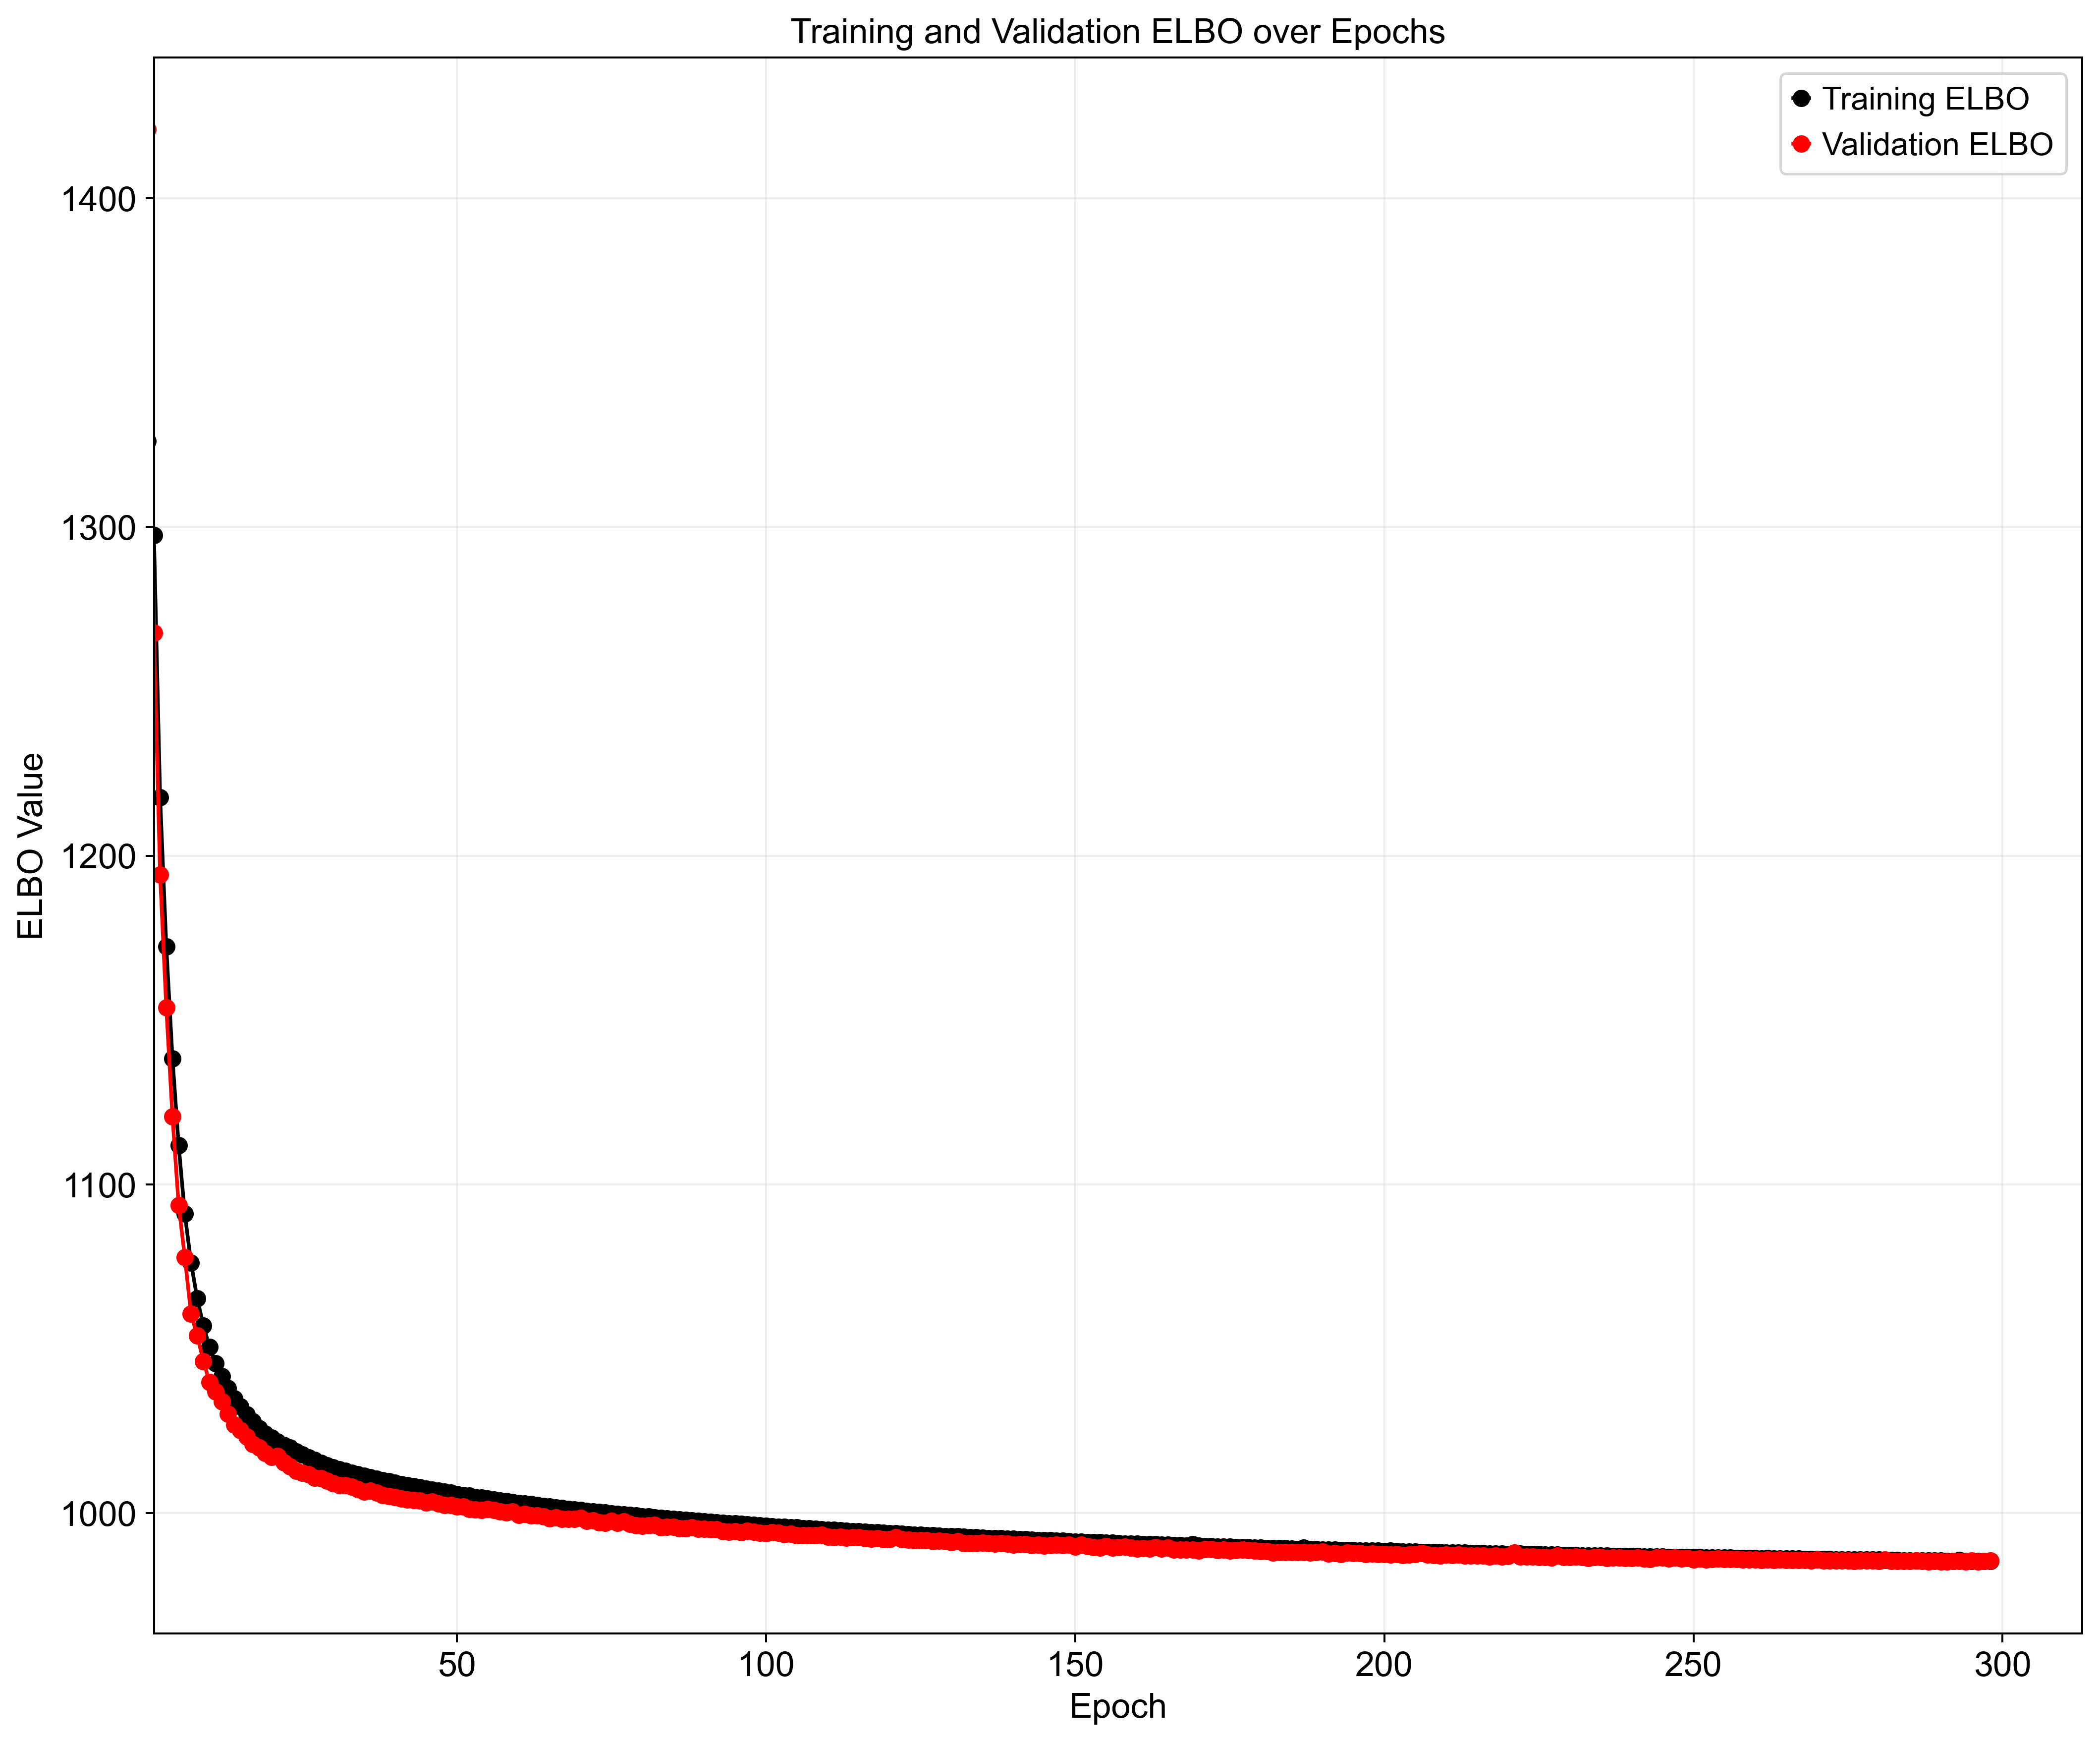

In [60]:
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

#plt.savefig(f'integration_of_remapped_data/mesenchymal_scvi_model_{timestamp}/scvi_cell_types_elbo.png', dpi=300, bbox_inches='tight')

#### Label transfer with `scANVI` 

In [61]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(scvi_model, 'Unknown')

In [62]:
scanvi_model.train(300, 
                     early_stopping = True,
                   check_val_every_n_epoch = 1, 
                   enable_progress_bar = True)

INFO     Training for 300 epochs.                                                                                  


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 300/300: 100%|███████| 300/300 [10:28:50<00:00, 88.51s/it, v_num=1, train_loss_step=1.01e+3, train_loss_epoch=980]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 300/300: 100%|██████| 300/300 [10:28:50<00:00, 125.77s/it, v_num=1, train_loss_step=1.01e+3, train_loss_epoch=980]


In [63]:
adata.obs["cellstates_scANVI"] = scanvi_model.predict(adata)

- Extract latent representation

In [64]:
adata.obsm["X_scANVI"] = scanvi_model.get_latent_representation(adata)

### Explore model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [65]:
history_df = (
    scanvi_model.history['elbo_train'].astype(float)
    .join(scanvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars = ['epoch'])
)

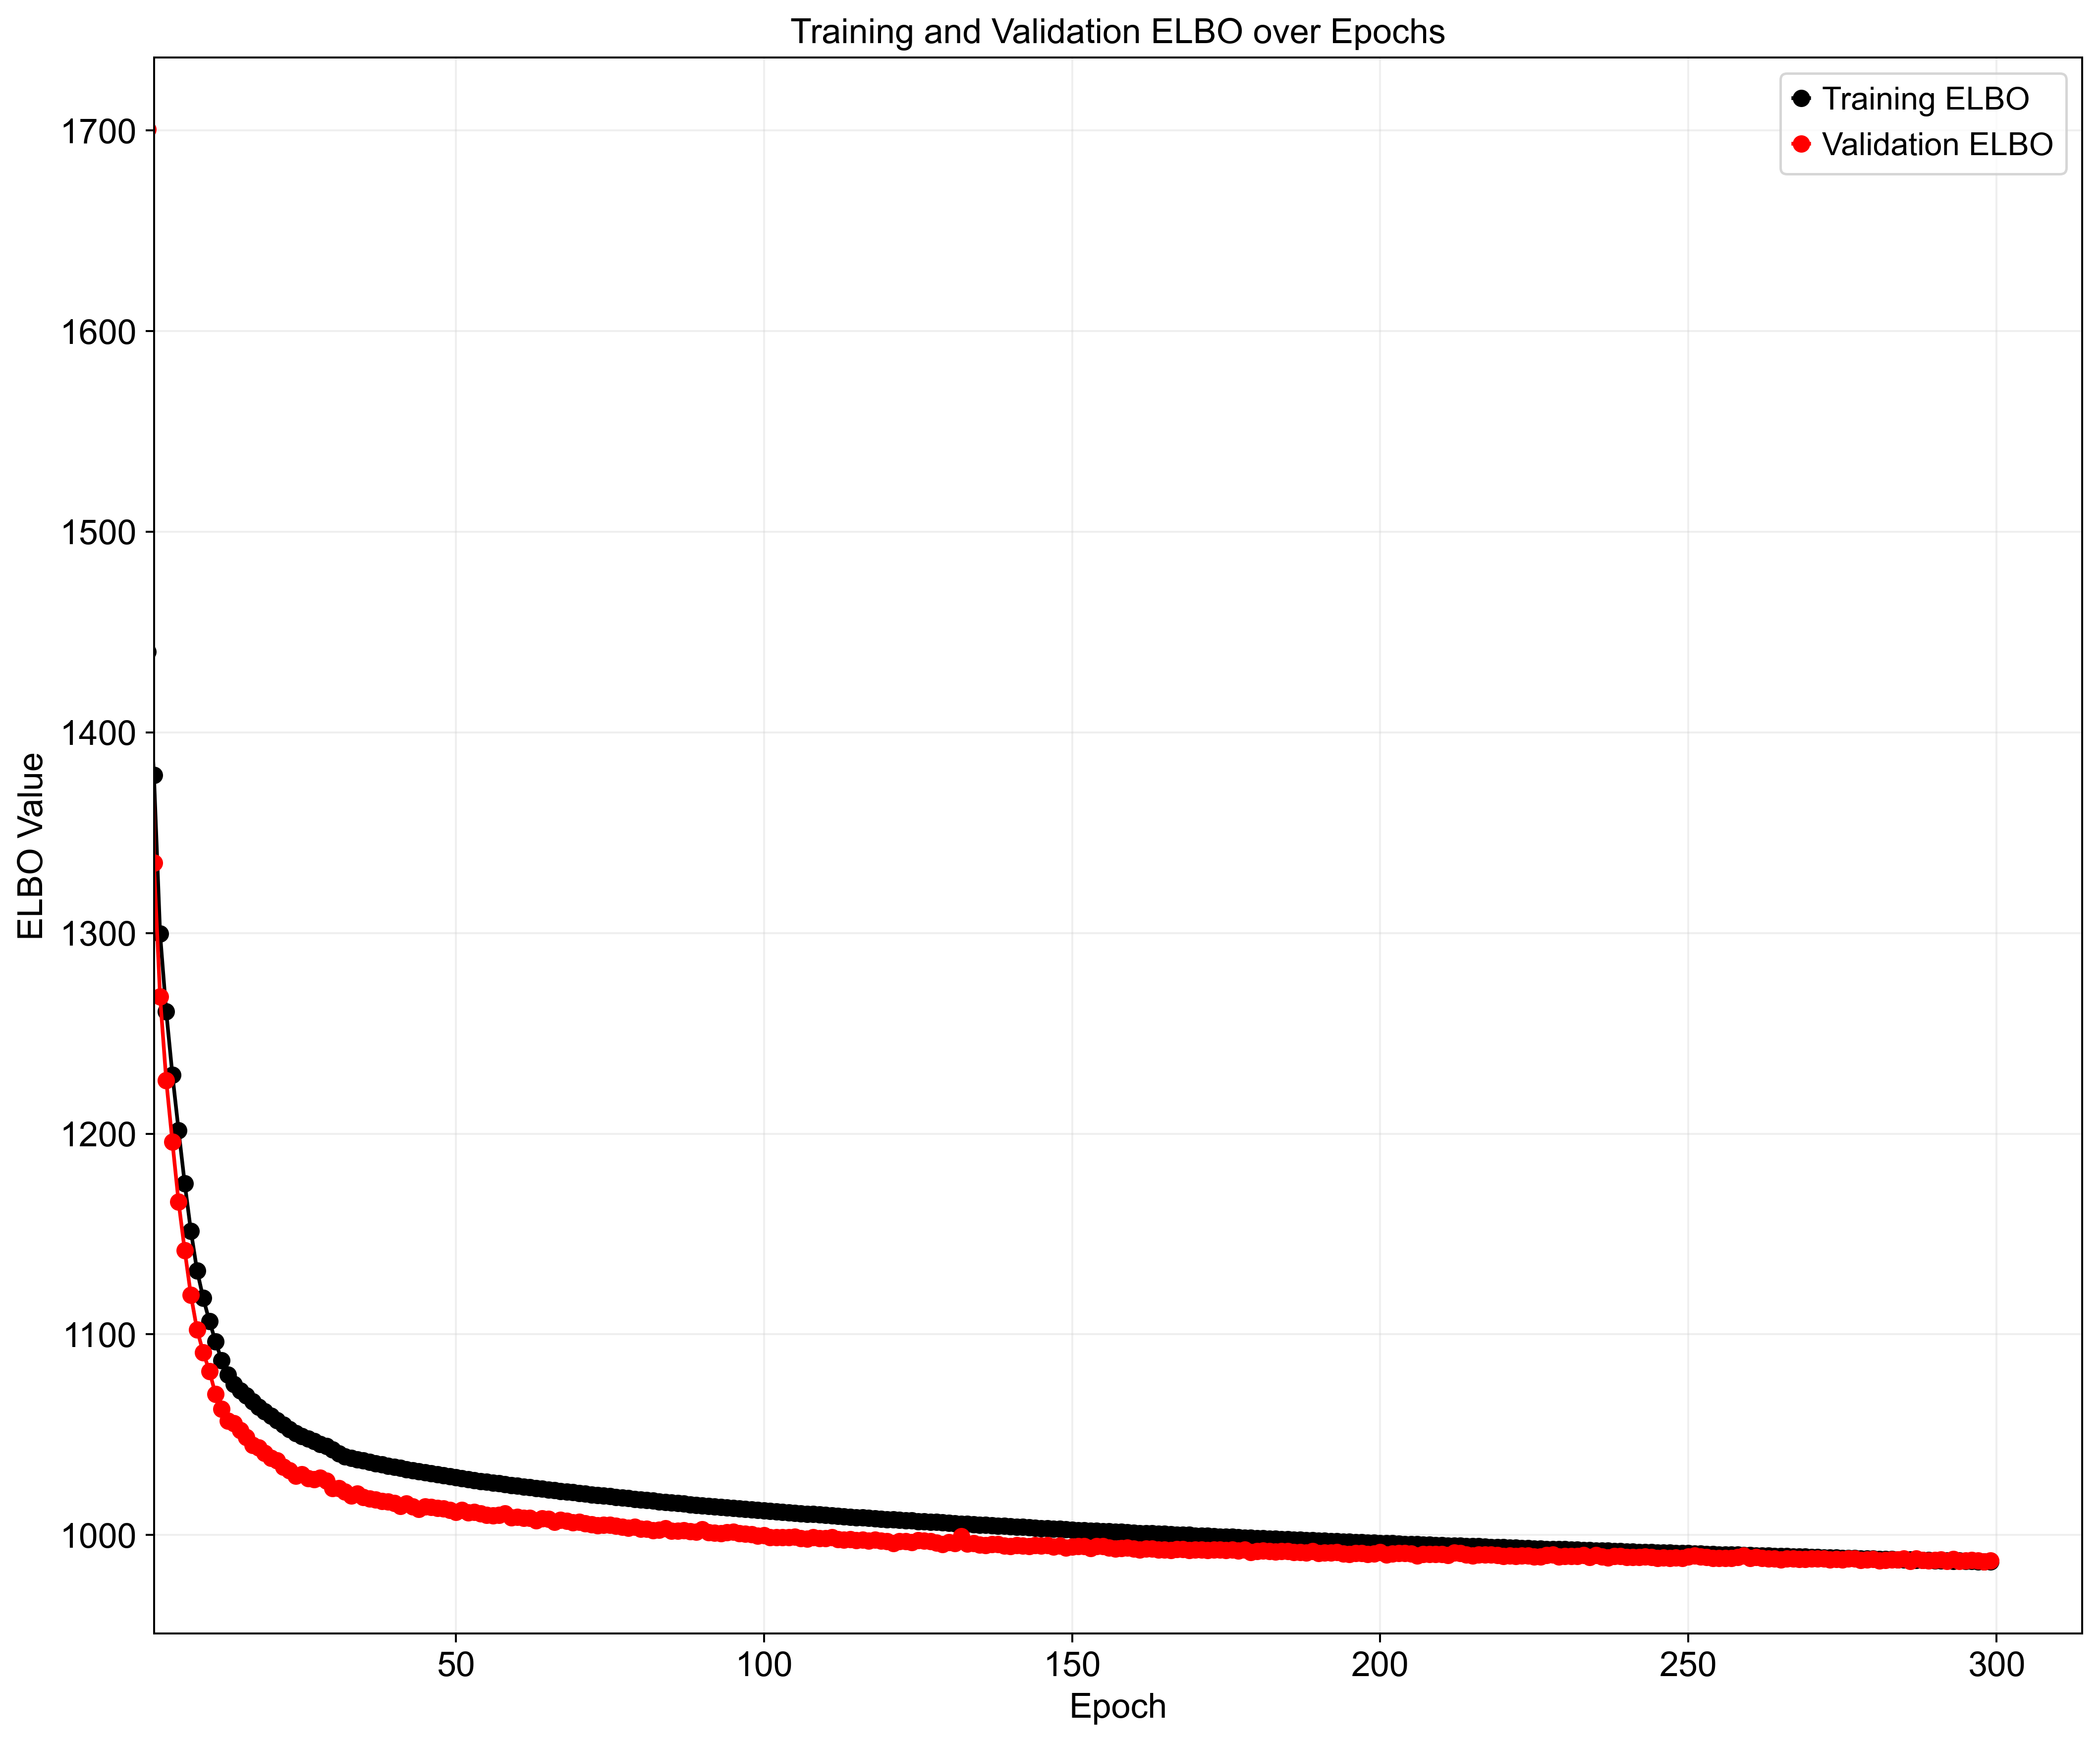

In [66]:
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

#plt.savefig(f'integration_of_remapped_data/mesenchymal_scanvi_model_{timestamp}/scanvi_cell_types_elbo.png', dpi=300, bbox_inches='tight')

In [67]:
posterior_probs = scanvi_model.predict(adata, soft=True)

In [68]:
confidence_scores = posterior_probs.max(axis=1)

In [69]:
adata.obs['confidence_score'] = confidence_scores

+ Visualize dataset

In [70]:
sc.pp.neighbors(adata, use_rep = "X_scANVI", n_neighbors = 150, metric = 'minkowski')
sc.tl.umap(adata, min_dist = 0.6, spread = 8, random_state = 1712)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:03:31)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:02:46)


In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata,color=["cellstates_scANVI", "confidence_score", 'cell_states', 'Integrated_05'], ncols=2, frameon=False, show=False, size = 3)
    plt.savefig(f"figures/mesenchymal_cellstates_transfer_categorical_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata,color=["Study_name", "ArrayExpress_ID", 'age_group', 'organism_part', 
                            'developmental_stage', 'library_preparation_protocol', 'immunophenotype', 'developmental_stage'], ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"figures/mesenchymal_cellstates_transfer_categorical_values2_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['sex', 'Cell_cycle_phase', 'sampling_site', 'full_age', 
                            'library_construnction_and_layout', 'Protocol REF', 'Performer', 'growth_condition', 
                            'Material Type', 'donor_id'], ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"figures/mesenchymal_cellstates_transfer_categorical_values3_{timestamp}.png", bbox_inches="tight")
    #plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['n_genes', 'n_counts', 'total_counts', 'n_genes_by_counts', 'predicted_doublets', 'percent_mito', 'percent_ribo', 'percent_hb'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"figures/mesenchymal_cellstates_transfer_continues_values_{timestamp}.png", bbox_inches="tight")
    #plt.show()

## Save prepared dataset

In [71]:
adata_export= adata_raw.copy()
adata_export

AnnData object with n_obs × n_vars = 185027 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoc

In [72]:
adata_export.obs['cellstates_scANVI'] = adata.obs['cellstates_scANVI'].copy()
adata_export.obs['confidence_score'] = adata.obs['confidence_score'].copy()
adata_export.obsm['X_scVI'] = adata.obsm['X_scVI'].copy()
adata_export.obsm['X_scANVI'] = adata.obsm['X_scANVI'].copy()
adata_export.obsm['X_pca'] = adata.obsm['X_pca'].copy()
adata_export.obsm['umap_uncorrected'] = adata.obsm['umap_uncorrected'].copy()
adata_export.obsm['X_umap'] = adata.obsm['X_umap'].copy()

In [73]:
current_history = adata_export.uns['processing_history'].tolist()

new_entry = json.dumps({
    'timestamp': timestamp,
    'step': 'Extracted genes (7000, library_preparation_protocol - batch) that were previously captured as highly variable, merged small populations into one group, fixed bolean nan issue, deleted samples with less than 10 cells, deleted doublets, predicted mesenchymal cell states using scVI-scANVI, scvi params: batch = sample_id, library_construnction_and_layout,Performer and Protocol REF, n_latent = 150, n_hidden = 256, n_layers = 3, dropout_rate = 0.1, dispersion = gene-cell, gene_likelihood = nb, 250 epochs, scanvi params: 300 epochs',
})
current_history.append(new_entry)

adata_export.uns['processing_history'] = current_history

In [74]:
adata_export.obs.rename(columns={'cell_id': 'cell_index'}, inplace=True)

In [75]:
adata_export.obs['time'] = adata_export.obs['time'].astype(str)

In [76]:
project = 'gut'
species = 'hs'
name = 'AM'
counts = 'raw'
atribute = 'all_datasets_scVI_scANVI_mesenchymal_cellstates'

adata_export.write_h5ad(f"data/gut_data/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")

In [77]:
adata.obs["cellstates_scANVI"].value_counts()

cellstates_scANVI
Mesoderm           70494
Stromal            44200
SMC                22427
Myofibroblast      19010
Pericyte           15702
Mesothelium        13159
ICC                   31
Lymphoid_Stroma        4
Name: count, dtype: int64